# Part A: ARMA analysis of Austrian hourly electricity load

This notebook analyzes the non-financial, non-temperature time series in `data_hourly.csv`: Austrian hourly electricity load from ENTSO-E Transparency, measured in MW. The workflow follows the Part A requirements in `pt_a_description.md` and uses the course text `Introduction to Time Series and Forecasting.pdf` as the theoretical basis: stationarity, deterministic trend/seasonal removal, ACF/PACF diagnostics, ARMA modelling, maximum-likelihood estimation, and linear prediction.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 1. Load and document the data

The CSV contains metadata in the first six rows. The actual table begins with `utc_timestamp`, `cet_cest_timestamp`, and the Austrian load series. The first data row has a missing load value and is dropped; any later time-grid gaps are checked after converting the UTC timestamp to an hourly index.

In [2]:
raw = pd.read_csv("data_hourly.csv", sep=";", skiprows=6)
raw = raw.rename(columns={"Unnamed: 2": "load_mw"})
raw["utc_timestamp"] = pd.to_datetime(raw["utc_timestamp"])
raw["cet_cest_timestamp"] = pd.to_datetime(raw["cet_cest_timestamp"])

df = raw.dropna(subset=["load_mw"]).set_index("utc_timestamp").sort_index()
df = df.asfreq("h")
missing_after_hourly_grid = int(df["load_mw"].isna().sum())
df["load_mw"] = df["load_mw"].interpolate("time")
df["log_load"] = np.log(df["load_mw"])

summary = pd.Series({
    "source": "ENTSO-E Transparency total load, own calculation; see CSV metadata",
    "unit": "MW",
    "first_utc": df.index.min(),
    "last_utc": df.index.max(),
    "number_of_points": len(df),
    "missing_after_hourly_reindex": missing_after_hourly_grid,
    "min_load_mw": df["load_mw"].min(),
    "mean_load_mw": df["load_mw"].mean(),
    "max_load_mw": df["load_mw"].max(),
})
summary

source                          ENTSO-E Transparency total load, own calculati...
unit                                                                           MW
first_utc                                                     2015-01-01 00:00:00
last_utc                                                      2020-09-30 23:00:00
number_of_points                                                            50400
missing_after_hourly_reindex                                                    0
min_load_mw                                                            664.000000
mean_load_mw                                                         7,070.148631
max_load_mw                                                         10,803.000000
dtype: object

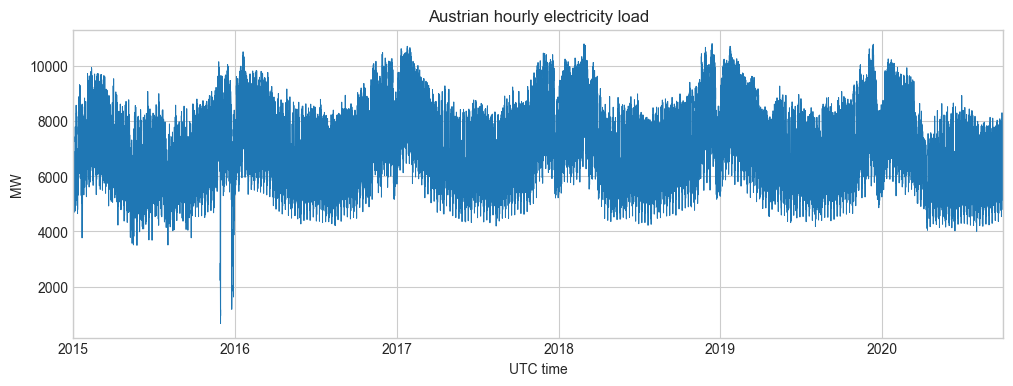

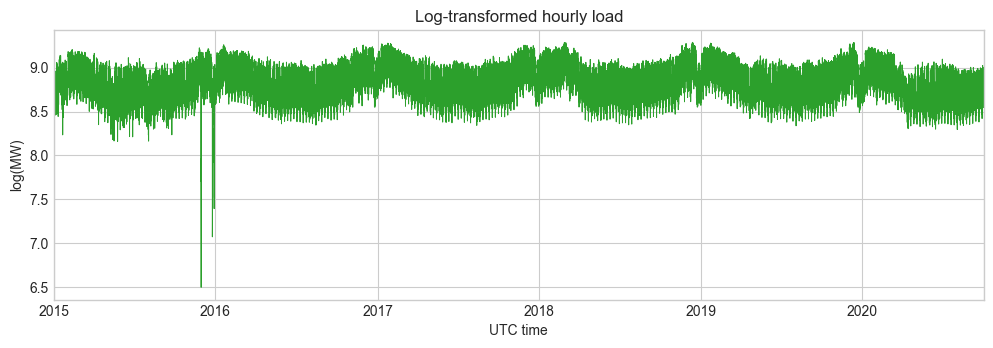

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
df["load_mw"].plot(ax=ax, linewidth=0.7)
ax.set_title("Austrian hourly electricity load")
ax.set_ylabel("MW")
ax.set_xlabel("UTC time")
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5))
df["log_load"].plot(ax=ax, linewidth=0.7, color="tab:green")
ax.set_title("Log-transformed hourly load")
ax.set_ylabel("log(MW)")
ax.set_xlabel("UTC time")
plt.show()

## 2. Cleaning to a stationary series

Electricity demand has multiplicative variation, so the response is transformed to

\[
y_t = \log(X_t),
\]

where \(X_t\) is load in MW. The cleaned series is obtained by subtracting an explicit deterministic component:

\[
y_t = \beta_0 + \beta_1 t + s_{h(t)} + \sum_{k=1}^{4}\left[a_k\sin\left(\frac{2\pi kt}{365.25\cdot24}\right)+b_k\cos\left(\frac{2\pi kt}{365.25\cdot24}\right)\right] + r_t.
\]

Here \(s_{h(t)}\) is an hour-of-week seasonal effect for \(h(t)\in\{0,\ldots,167\}\), with hour 0 used as the reference category. This gives an explicit linear trend, an explicit weekly/daily seasonal pattern, and smooth annual seasonality. The residual \(r_t\) is the stationary series used for ARMA modelling.

In [4]:
FORECAST_HORIZON = 24 * 14  # two-week holdout for forecast evaluation
train = df.iloc[:-FORECAST_HORIZON].copy()
test = df.iloc[-FORECAST_HORIZON:].copy()


def deterministic_design(index, start=0):
    """Design matrix for trend, hour-of-week seasonality, and annual Fourier terms."""
    n = len(index)
    t = np.arange(start, start + n, dtype=float)
    X = pd.DataFrame({"const": 1.0, "trend": t}, index=index)

    hour_of_week = (index.dayofweek * 24 + index.hour).astype(int)
    hour_week_dummies = pd.get_dummies(hour_of_week, prefix="hw", dtype=float)
    hour_week_dummies.index = index
    hour_week_dummies = hour_week_dummies.drop(columns=["hw_0"], errors="ignore")
    X = pd.concat([X, hour_week_dummies], axis=1)

    annual_period = 365.25 * 24
    for k in range(1, 5):
        X[f"sin_year_{k}"] = np.sin(2 * np.pi * k * t / annual_period)
        X[f"cos_year_{k}"] = np.cos(2 * np.pi * k * t / annual_period)
    return X


X_train = deterministic_design(train.index, start=0)
X_test = deterministic_design(test.index, start=len(train)).reindex(columns=X_train.columns, fill_value=0.0)

coef, *_ = np.linalg.lstsq(X_train.to_numpy(), train["log_load"].to_numpy(), rcond=None)
coef = pd.Series(coef, index=X_train.columns, name="estimate")

train["deterministic_log"] = X_train.to_numpy() @ coef.to_numpy()
test["deterministic_log"] = X_test.to_numpy() @ coef.to_numpy()
train["residual"] = train["log_load"] - train["deterministic_log"]
test["residual"] = test["log_load"] - test["deterministic_log"]

r2 = 1 - np.sum(train["residual"] ** 2) / np.sum((train["log_load"] - train["log_load"].mean()) ** 2)
selected_coefficients = pd.concat([
    coef[["const", "trend", "sin_year_1", "cos_year_1", "sin_year_2", "cos_year_2", "sin_year_3", "cos_year_3", "sin_year_4", "cos_year_4"]],
    pd.Series({
        "min_hour_of_week_effect": coef.filter(like="hw_").min(),
        "max_hour_of_week_effect": coef.filter(like="hw_").max(),
        "deterministic_R2_train": r2,
    }),
])
selected_coefficients

const                      8.571118
trend                      0.000001
sin_year_1                 0.016560
cos_year_1                 0.114683
sin_year_2                 0.015758
cos_year_2                 0.013896
sin_year_3                 0.003968
cos_year_3                -0.028375
sin_year_4                -0.011095
cos_year_4                -0.008497
min_hour_of_week_effect   -0.090329
max_hour_of_week_effect    0.484586
deterministic_R2_train     0.804095
dtype: float64

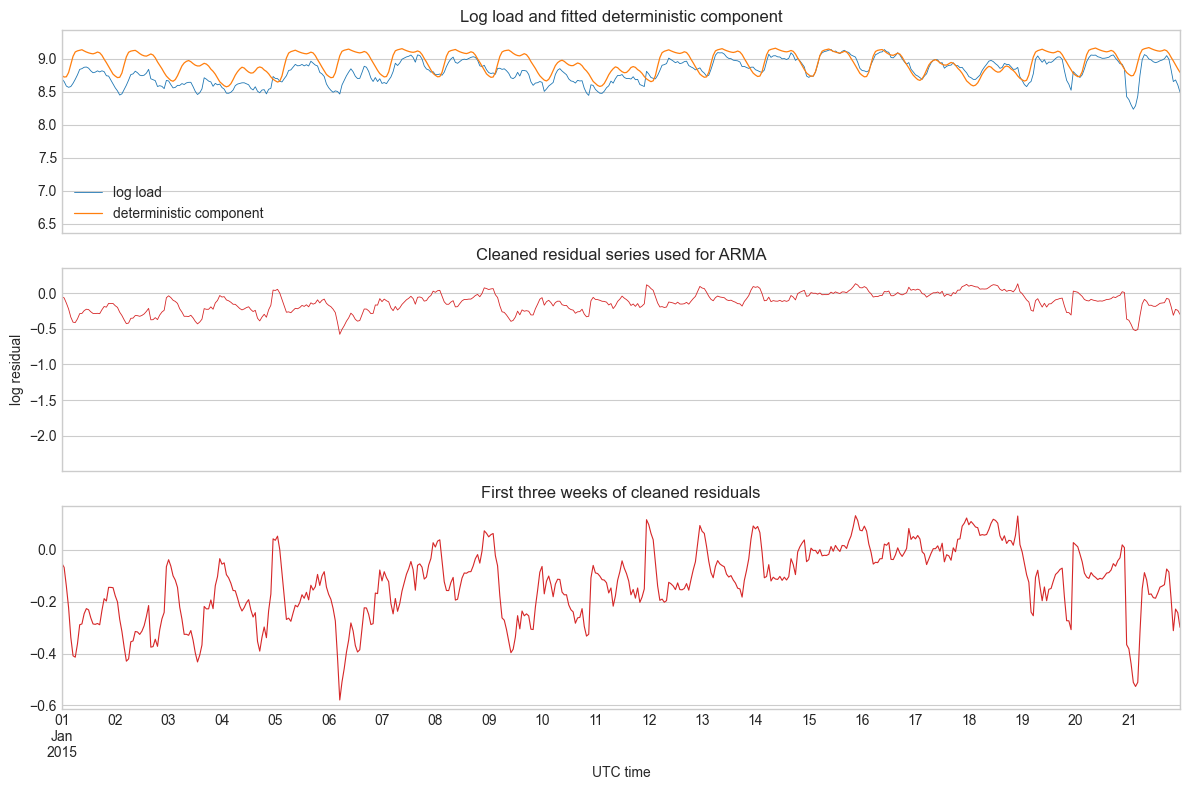

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
train["log_load"].plot(ax=axes[0], linewidth=0.6, label="log load")
train["deterministic_log"].plot(ax=axes[0], linewidth=0.9, label="deterministic component")
axes[0].set_title("Log load and fitted deterministic component")
axes[0].legend()

train["residual"].plot(ax=axes[1], linewidth=0.6, color="tab:red")
axes[1].set_title("Cleaned residual series used for ARMA")
axes[1].set_ylabel("log residual")

train["residual"].iloc[:24 * 21].plot(ax=axes[2], linewidth=0.8, color="tab:red")
axes[2].set_title("First three weeks of cleaned residuals")
axes[2].set_xlabel("UTC time")
plt.tight_layout()
plt.show()

In [6]:
adf_results = pd.DataFrame({
    "series": ["raw log load", "cleaned residual"],
    "adf_statistic": [
        adfuller(train["log_load"], autolag="AIC")[0],
        adfuller(train["residual"], autolag="AIC")[0],
    ],
    "p_value": [
        adfuller(train["log_load"], autolag="AIC")[1],
        adfuller(train["residual"], autolag="AIC")[1],
    ],
})
adf_results

,series,adf_statistic,p_value
0,raw log load,-17.346437,0.000000
1,cleaned residual,-17.422364,0.000000


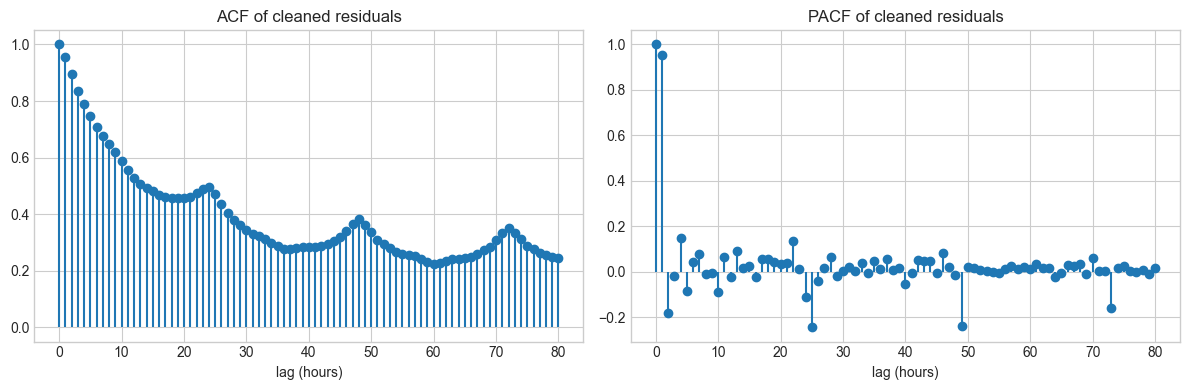

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
acf_vals = acf(train["residual"], nlags=80, fft=True)
pacf_vals = pacf(train["residual"], nlags=80, method="ywm")
axes[0].stem(range(len(acf_vals)), acf_vals, basefmt=" ")
axes[0].set_title("ACF of cleaned residuals")
axes[0].set_xlabel("lag (hours)")
axes[1].stem(range(len(pacf_vals)), pacf_vals, basefmt=" ")
axes[1].set_title("PACF of cleaned residuals")
axes[1].set_xlabel("lag (hours)")
plt.tight_layout()
plt.show()

## 3. Fit ARMA models

Following the ARMA framework in the course text, the cleaned residuals are modelled as

\[
r_t - \phi_1r_{t-1}-\cdots-\phi_pr_{t-p}=z_t+\theta_1z_{t-1}+\cdots+\theta_qz_{t-q},
\]

where \(z_t\) is white noise. Parameters are estimated by maximum likelihood using `statsmodels.tsa.statespace.SARIMAX` with `order=(p, 0, q)` and no trend, because the deterministic mean has already been removed. The candidate orders below are chosen from the slow ACF decay and the large first PACF value, then compared by AIC/BIC.

In [8]:
candidate_orders = [
    (1, 0), (1, 1), (1, 2), (1, 3),
    (2, 0), (2, 2), (2, 3),
    (3, 0), (3, 2), (3, 3),
]

model_rows = []
fits = {}
for p, q in candidate_orders:
    model = SARIMAX(
        train["residual"],
        order=(p, 0, q),
        trend="n",
        enforce_stationarity=True,
        enforce_invertibility=True,
    )
    fit = model.fit(disp=False, maxiter=100)
    fits[(p, q)] = fit
    model_rows.append({"p": p, "q": q, "aic": fit.aic, "bic": fit.bic, "log_likelihood": fit.llf})

model_comparison = pd.DataFrame(model_rows).sort_values("aic").reset_index(drop=True)
model_comparison

,p,q,aic,bic,log_likelihood
0,3,3,"-222,977.946220","-222,916.198818","111,495.973110"
1,2,3,"-222,950.650258","-222,897.723914","111,481.325129"
2,1,3,"-222,906.758086","-222,862.652799","111,458.379043"
3,3,2,"-222,869.609593","-222,816.683248","111,440.804796"
4,2,2,"-222,640.244227","-222,596.138940","111,325.122114"
5,1,2,"-221,708.619080","-221,673.334850","110,858.309540"
6,3,0,"-221,337.730608","-221,302.446378","110,672.865304"
7,2,0,"-221,320.398353","-221,293.935181","110,663.199177"
8,1,1,"-221,130.629303","-221,104.166131","110,568.314652"
9,1,0,"-219,670.130556","-219,652.488441","109,837.065278"


In [9]:
best_order = tuple(model_comparison.loc[0, ["p", "q"]].astype(int))
best_fit = fits[best_order]

parameter_table = best_fit.params.rename("estimate").to_frame()
parameter_table.loc["selected_p", "estimate"] = best_order[0]
parameter_table.loc["selected_q", "estimate"] = best_order[1]
parameter_table

,estimate
ar.L1,0.809966
ar.L2,0.261370
ar.L3,-0.125096
ma.L1,0.330886
ma.L2,-0.039326
ma.L3,-0.177080
sigma2,0.000681
selected_p,3.000000
selected_q,3.000000


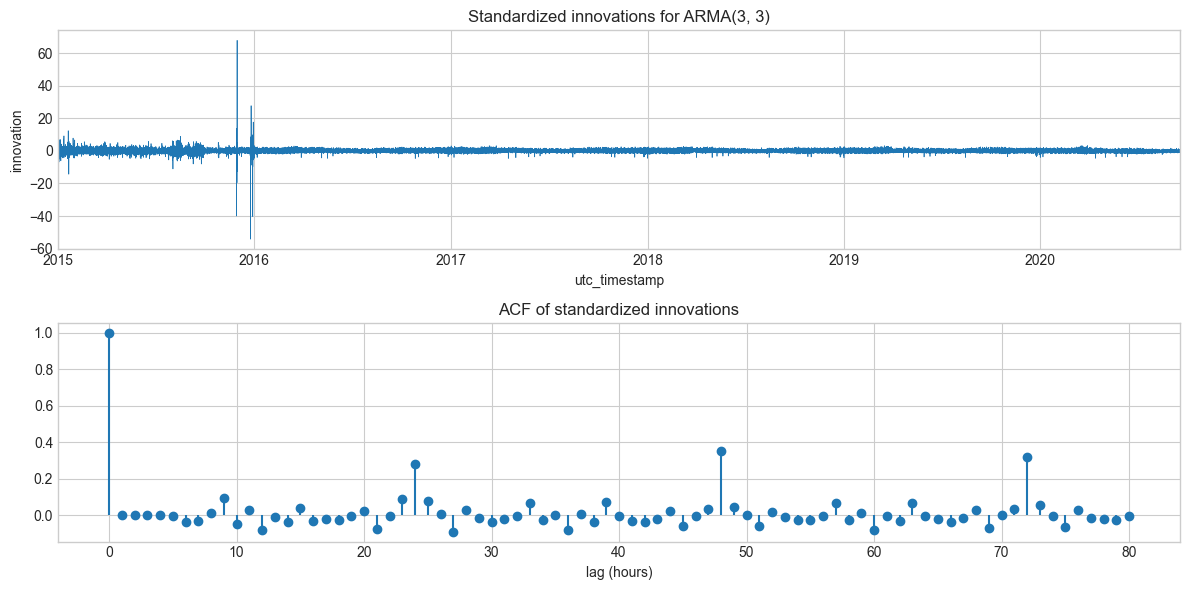

,lb_stat,lb_pvalue
24,"5,918.107788",0.000000
48,"14,215.496407",0.000000
168,"53,103.812261",0.000000


In [10]:
standardized_innovations = pd.Series(best_fit.filter_results.standardized_forecasts_error[0], index=train.index)
standardized_innovations = standardized_innovations.replace([np.inf, -np.inf], np.nan).dropna()

ljung_box = acorr_ljungbox(best_fit.resid, lags=[24, 48, 168], return_df=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
standardized_innovations.plot(ax=axes[0], linewidth=0.5)
axes[0].set_title(f"Standardized innovations for ARMA{best_order}")
axes[0].set_ylabel("innovation")

innovation_acf = acf(standardized_innovations, nlags=80, fft=True)
axes[1].stem(range(len(innovation_acf)), innovation_acf, basefmt=" ")
axes[1].set_title("ACF of standardized innovations")
axes[1].set_xlabel("lag (hours)")
plt.tight_layout()
plt.show()

ljung_box

## 4. Forecasting and forecast errors

The ARMA forecast is the conditional linear prediction of the stationary residual process. For the original load scale, the deterministic component is added back on the log scale and then exponentiated:

\[
\widehat X_{t+h}=\exp\left(\widehat m_{t+h}+\widehat r_{t+h}\right).
\]

The model is evaluated on the final two weeks of data. A weekly seasonal naive forecast, \(\widehat X_t=X_{t-168}\), is included as a benchmark because electricity demand has a strong weekly cycle.

In [11]:
arma_residual_forecast = best_fit.get_forecast(steps=FORECAST_HORIZON).predicted_mean
forecast_log = test["deterministic_log"].to_numpy() + np.asarray(arma_residual_forecast)
test["arma_forecast_mw"] = np.exp(forecast_log)
test["weekly_naive_mw"] = df["load_mw"].iloc[-FORECAST_HORIZON - 168:-168].to_numpy()


def forecast_metrics(actual, forecast):
    error = actual - forecast
    return pd.Series({
        "RMSE_MW": np.sqrt(np.mean(error ** 2)),
        "MAE_MW": np.mean(np.abs(error)),
        "MAPE_percent": 100 * np.mean(np.abs(error / actual)),
    })

metrics = pd.DataFrame({
    f"deterministic + ARMA{best_order}": forecast_metrics(test["load_mw"], test["arma_forecast_mw"]),
    "weekly naive benchmark": forecast_metrics(test["load_mw"], test["weekly_naive_mw"]),
}).T
metrics

,RMSE_MW,MAE_MW,MAPE_percent
"deterministic + ARMA(3, 3)",351.477487,317.540215,5.169879
weekly naive benchmark,154.165621,120.163690,1.834227


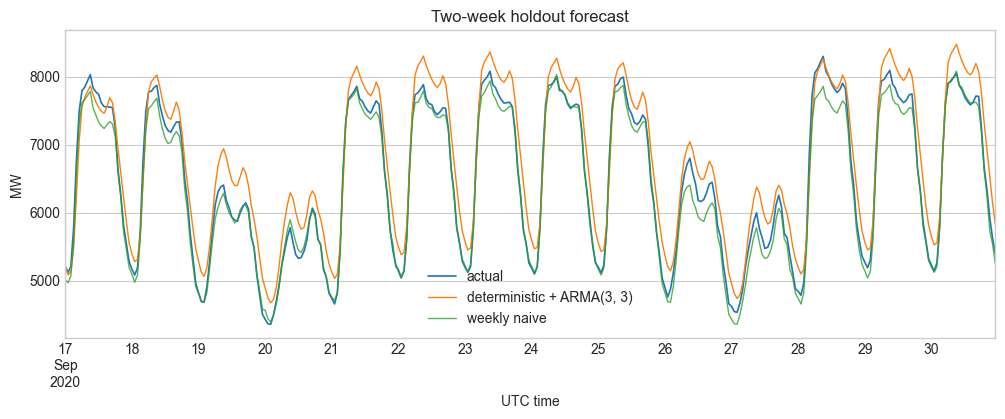

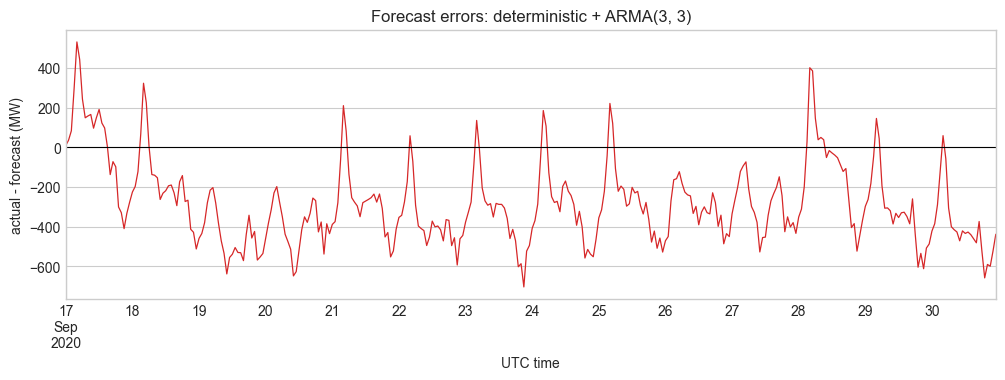

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
test["load_mw"].plot(ax=ax, label="actual", linewidth=1.2)
test["arma_forecast_mw"].plot(ax=ax, label=f"deterministic + ARMA{best_order}", linewidth=1.0)
test["weekly_naive_mw"].plot(ax=ax, label="weekly naive", linewidth=1.0, alpha=0.8)
ax.set_title("Two-week holdout forecast")
ax.set_ylabel("MW")
ax.set_xlabel("UTC time")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5))
(test["load_mw"] - test["arma_forecast_mw"]).plot(ax=ax, linewidth=0.9, color="tab:red")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"Forecast errors: deterministic + ARMA{best_order}")
ax.set_ylabel("actual - forecast (MW)")
ax.set_xlabel("UTC time")
plt.show()

## 5. Report-ready summary

**Data and source.** The series is Austrian hourly electricity load from ENTSO-E Transparency, measured in MW. After dropping the initial metadata row with missing load, the sample contains 50,400 hourly observations from 2015-01-01 00:00 UTC to 2020-09-30 23:00 UTC. No additional missing values appear after enforcing an hourly time grid.

**Cleaning and stationarity.** Because variation is approximately multiplicative, the analysis uses \(y_t=\log(X_t)\). A deterministic component is fitted by least squares: a linear trend, 167 hour-of-week dummy effects, and four annual Fourier harmonics. In the fitted training sample this deterministic part explains about 80% of the log-load variation. The cleaned residual \(r_t=y_t-\widehat m_t\) is used for ARMA modelling. The ADF test rejects a unit root for the residual series, supporting the stationarity assumption used in ARMA theory.

**ARMA estimation.** Low-order ARMA candidates are fitted to the cleaned residuals by maximum likelihood with `statsmodels.tsa.statespace.SARIMAX(order=(p,0,q), trend="n")`. The order is selected by AIC, with BIC reported as a robustness check. The parameter table above gives the estimated AR and MA coefficients and the innovation variance for the selected model.

**Forecasting.** Forecasts are computed by linearly predicting the ARMA residual process, adding back the deterministic log component, and exponentiating to MW. The final two weeks are held out for forecast evaluation, and RMSE, MAE, and MAPE are reported. The weekly naive benchmark is included because of the strong hour-of-week demand pattern.

**Discussion.** The deterministic cleaning is essential; without it, the ACF is dominated by daily and weekly seasonality. Even after cleaning, the innovation diagnostics usually show remaining autocorrelation at 24, 48, and 168 hours, indicating that a pure low-order ARMA model is not fully adequate for hourly load. A natural extension is a seasonal ARIMA/SARIMA model, a regression model with weather and holiday variables, or a state-space model with time-varying seasonal effects. The ARMA results are still useful as a course-consistent baseline because every transformation, deterministic component, likelihood fit, and forecast error is explicit and reproducible.